<a href="https://colab.research.google.com/github/divyaraut17/Deep-Learning/blob/main/DL_Exp_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Define a simple moedel**

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

#load dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

#normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

#model function
def create_model():
  model = keras.Sequential([
      layers.Flatten(input_shape=(28, 28)),
      layers.Dense(256, activation='relu'),
      layers.Dense(128, activation='relu'),
      layers.Dense(10, activation='softmax')
  ])
  return model



**Fixed Learning Rate**

In [ ]:
model_fixed = create_model()
model_fixed.compile(optimizer=keras.optimizers.Adam(learning_rate=0.01),
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy']
                    )
history_fixed = model_fixed.fit(
    x_train, y_train,
    epochs=20,
    validation_split=0.2,
    batch_size=128
  )

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.8676 - loss: 0.4242 - val_accuracy: 0.9582 - val_loss: 0.1364
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9614 - loss: 0.1291 - val_accuracy: 0.9612 - val_loss: 0.1339
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9704 - loss: 0.0989 - val_accuracy: 0.9670 - val_loss: 0.1299
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9750 - loss: 0.0823 - val_accuracy: 0.9672 - val_loss: 0.1281
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9777 - loss: 0.0742 - val_accuracy: 0.9657 - val_loss: 0.1436
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9805 - loss: 0.0639 - val_accuracy: 0.9651 - val_loss: 0.1423
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9809 - loss: 0.0677 - val_accuracy: 0.9680 - val_loss: 0.1396
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9817 - loss: 0.0621 - val_accuracy:

**Step Decay**

In [ ]:
import math
from tensorflow.keras import callbacks

# Create and compile the model
model = create_model()
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Define the step decay logic
def step_decay(epoch):
    initial_lrate = 0.01
    drop = 0.5
    epochs_drop = 10.0
    # Equation: lrate = initial * (drop ^ floor(epoch / epochs_drop))
    lrate = initial_lrate * math.pow(drop, math.floor((1+epoch)/epochs_drop))
    return lrate

# Initialize the scheduler callback
lr_scheduler = callbacks.LearningRateScheduler(step_decay, verbose=1)

# Usage in model.fit
history = model.fit(
    x_train, y_train,
    epochs=20,
    validation_data=(x_test, y_test), # Using x_test, y_test as validation data
    callbacks=[lr_scheduler]
)


Epoch 1: LearningRateScheduler setting learning rate to 0.01.
Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8887 - loss: 0.3716 - val_accuracy: 0.9338 - val_loss: 0.2430 - learning_rate: 0.0100

Epoch 2: LearningRateScheduler setting learning rate to 0.01.
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9505 - loss: 0.1805 - val_accuracy: 0.9572 - val_loss: 0.1729 - learning_rate: 0.0100

Epoch 3: LearningRateScheduler setting learning rate to 0.01.
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9600 - loss: 0.1579 - val_accuracy: 0.9549 - val_loss: 0.2002 - learning_rate: 0.0100

Epoch 4: LearningRateScheduler setting learning rate to 0.01.
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9640 - loss: 0.1379 - val_accuracy: 0.9640 - val_loss: 0.1699 - learning_rate: 0.0100

Epoch 5: LearningRateScheduler setting learning rate to 0.01.
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy

**Exponential Decay**

In [ ]:
# Define the schedule
lr_schedule = optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.01,
    decay_steps=10000, # Number of steps before decreasing
    decay_rate=0.96,   # The base of the exponential
    staircase=False    # Set to True for a step-like effect
)
model_exp = create_model()
model_exp.compile(optimizer=optimizers.Adam(learning_rate=lr_schedule),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

history_exp = model_exp.fit(
    x_train, y_train,
    epochs=20,
    validation_split=0.2,
    batch_size=128
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.8613 - loss: 0.4282 - val_accuracy: 0.9532 - val_loss: 0.1583
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9605 - loss: 0.1299 - val_accuracy: 0.9536 - val_loss: 0.1607
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9714 - loss: 0.0979 - val_accuracy: 0.9615 - val_loss: 0.1339
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9729 - loss: 0.0914 - val_accuracy: 0.9697 - val_loss: 0.1240
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9783 - loss: 0.0703 - val_accuracy: 0.9657 - val_loss: 0.1364
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9774 - loss: 0.0787 - val_accuracy: 0.9699 - val_loss: 0.1243
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9789 - loss: 0.0762 - val_accuracy: 0.9596 - val_loss: 0.1849
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9816 - loss: 0.0665 - val_accuracy

**ReduceLRonPlateau**

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# Create and compile the model with a simple Adam optimizer
model = create_model()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Learning Rate Decay: Reduces LR by factor of 0.2 if val_loss plateaus for 3 epochs
lr_decay = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=0.00001,
    verbose=1
)

# 3. Train the Model
# Pass the callbacks list to the fit function
history = model.fit(
    x_train, y_train,
    epochs=20,
    validation_data=(x_test, y_test),
    callbacks=[lr_decay]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8811 - loss: 0.3911 - val_accuracy: 0.9525 - val_loss: 0.1857 - learning_rate: 0.0100
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9494 - loss: 0.1871 - val_accuracy: 0.9569 - val_loss: 0.1769 - learning_rate: 0.0100
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9615 - loss: 0.1466 - val_accuracy: 0.9565 - val_loss: 0.1799 - learning_rate: 0.0100
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9632 - loss: 0.1451 - val_accuracy: 0.9619 - val_loss: 0.1749 - learning_rate: 0.0100
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9685 - loss: 0.1276 - val_accuracy: 0.9560 - val_loss: 0.1969 - learning_rate: 0.0100
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.9696 - loss: 0.1199 - val_accuracy: 0.9527 - val_loss: 0.2050 - learning_rate: 0.0100
Epoch 7/20
1865/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.97

**Early Stopping**

In [ ]:
# Early Stopping: Stops training if validation loss doesn't improve for 5 epochs
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
model_early = create_model()
model_early.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])
history_early = model_early.fit(
    x_train, y_train,
    epochs=20,
    validation_split=0.2,
    batch_size=128,
    callbacks=[early_stop]
)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8663 - loss: 0.4188 - val_accuracy: 0.9600 - val_loss: 0.1359
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9638 - loss: 0.1204 - val_accuracy: 0.9603 - val_loss: 0.1388
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9722 - loss: 0.0952 - val_accuracy: 0.9661 - val_loss: 0.1211
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9759 - loss: 0.0775 - val_accuracy: 0.9638 - val_loss: 0.1429
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9762 - loss: 0.0842 - val_accuracy: 0.9659 - val_loss: 0.1398
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9807 - loss: 0.0647 - val_accuracy: 0.9534 - val_loss: 0.1993
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9789 - loss: 0.0760 - val_accuracy: 0.9661 - val_loss: 0.1558
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9798 - loss: 0.0713 - val_accuracy

**Comparative Analysis of Different LR Scheduling Techniques**

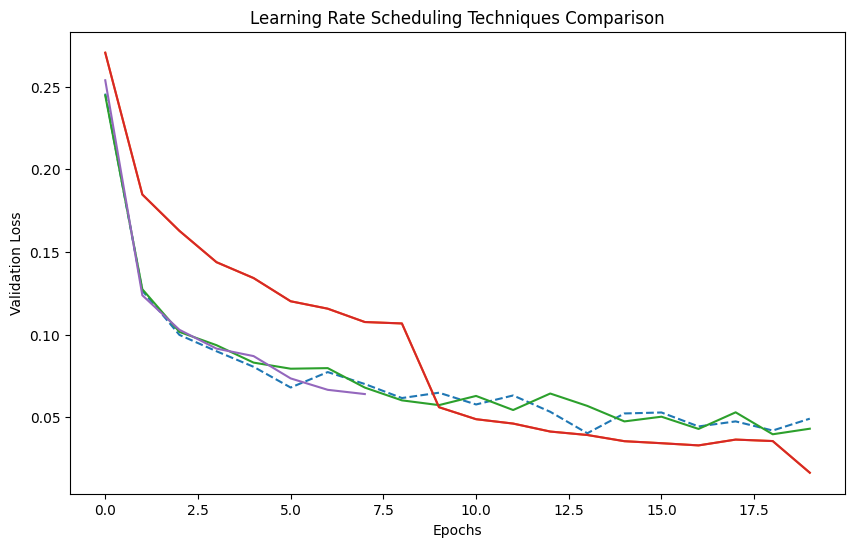

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(history_fixed.history['loss'], label='Fixed Learning Rate', linestyle='--')
plt.plot(history.history['loss'], label='Step Decay')
plt.plot(history_exp.history['loss'], label='Exponential Decay')
plt.plot(history.history['loss'], label='ReduceLROnPlateau')
plt.plot(history_early.history['loss'], label='Early Stopping')

plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.title('Learning Rate Scheduling Techniques Comparison')
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


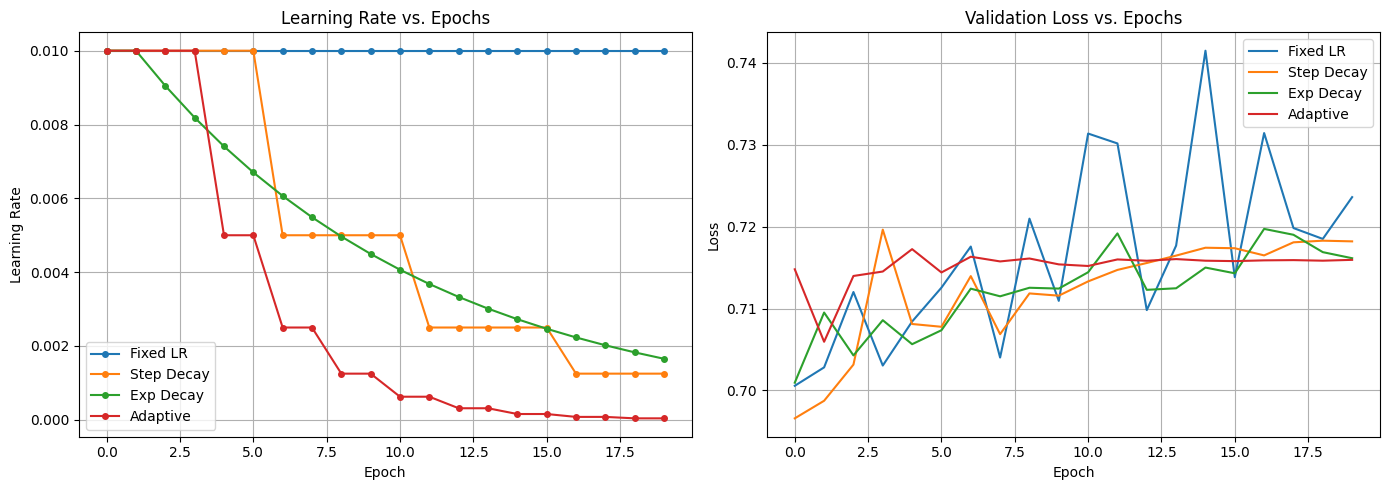

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
import matplotlib.pyplot as plt

# 1. Setup Synthetic Data (to ensure the code runs without external datasets)
x_train = np.random.random((1000, 20))
y_train = np.random.randint(0, 2, (1000,))
x_val = np.random.random((200, 20))
y_val = np.random.randint(0, 2, (200,))

# 2. Scheduling Functions
def step_decay(epoch):
    initial_lr = 0.01
    drop = 0.5
    epochs_drop = 5
    return float(initial_lr * (drop ** (epoch // epochs_drop)))

def exp_decay(epoch):
    initial_lr = 0.01
    k = 0.1
    return float(initial_lr * np.exp(-k * epoch))

# 3. Training Function
def train_model(name, callback_list=None, initial_lr=0.01):
    model = models.Sequential([
        layers.Dense(64, activation='relu', input_shape=(20,)),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=optimizers.Adam(learning_rate=initial_lr),
                  loss='binary_crossentropy')

    # Custom callback to capture LR at each epoch
    class LRHistory(callbacks.Callback):
        def on_epoch_begin(self, epoch, logs=None):
            if not hasattr(self, 'lrs'): self.lrs = []
            self.lrs.append(float(tf.keras.backend.get_value(self.model.optimizer.learning_rate)))

    lr_tracker = LRHistory()
    cbs = [lr_tracker] + (callback_list if callback_list else [])

    history = model.fit(x_train, y_train, epochs=20, validation_data=(x_val, y_val),
                        callbacks=cbs, verbose=0)
    return history.history['val_loss'], lr_tracker.lrs

# 4. Run Comparisons
results = {
    'Fixed LR': train_model('Fixed'),
    'Step Decay': train_model('Step', [callbacks.LearningRateScheduler(step_decay)]),
    'Exp Decay': train_model('Exp', [callbacks.LearningRateScheduler(exp_decay)]),
    'Adaptive': train_model('Adaptive', [callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)])
}

# 5. Visualization
plt.figure(figsize=(14, 5))

# Plot 1: Learning Rate Behavior
plt.subplot(1, 2, 1)
for name, (loss, lrs) in results.items():
    plt.plot(lrs, label=name, marker='o', markersize=4)
plt.title('Learning Rate vs. Epochs')
plt.xlabel('Epoch'); plt.ylabel('Learning Rate'); plt.legend(); plt.grid(True)

# Plot 2: Convergence (Validation Loss)
plt.subplot(1, 2, 2)
for name, (loss, lrs) in results.items():
    plt.plot(loss, label=name)
plt.title('Validation Loss vs. Epochs')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)

plt.tight_layout()
plt.show()